# Double Pendulum

Rebuilt from `legacy/Double Pendulum.ipynb` through the shared
`lagrangian.py` engine instead of hand-derived Euler-Lagrange equations.
Same physical setup: `m1=2, m2=1, L1=2, L2=1`, chaotic initial condition
`(theta1, omega1, theta2, omega2) = (1, -1, 1, 4)`.

No closed-form solution exists for the double pendulum (that's the point --
it's chaotic), so validation here is: (1) energy conservation over a long
run, since a real Lagrangian system conserves `T+U` regardless of how
chaotic the trajectory looks, and (2) at small amplitude the nonlinear
system should reduce to its own linearization, checked via
`lagrangian.linearize()`.

In [1]:
import os
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import lagrangian as lg

os.makedirs('media', exist_ok=True)

In [2]:
t, g, m1, m2, L1, L2 = sp.symbols('t g m1 m2 L1 L2')
the1 = sp.Function('the1')(t)
the2 = sp.Function('the2')(t)

x1 = L1 * sp.sin(the1)
y1 = -L1 * sp.cos(the1)
x2 = x1 + L2 * sp.sin(the2)
y2 = y1 - L2 * sp.cos(the2)

T = 0.5 * m1 * (sp.diff(x1, t)**2 + sp.diff(y1, t)**2) + 0.5 * m2 * (sp.diff(x2, t)**2 + sp.diff(y2, t)**2)
U = m1 * g * y1 + m2 * g * y2
L = T - U

sols, coords_d, coords_dd = lg.euler_lagrange(L, [the1, the2], t)
dSdt = lg.build_ode_system(sols, [the1, the2], coords_d, t, (g, m1, m2, L1, L2))
energy = lg.energy_fn(T, U, [the1, the2], coords_d, (g, m1, m2, L1, L2))
sols[coords_dd[0]]

(-0.25*L1*m2*sin(2*the1(t) - 2*the2(t))*Derivative(the1(t), t)**2 - 0.5*L2*m2*sin(the1(t) - the2(t))*Derivative(the2(t), t)**2 - 0.5*g*m1*sin(the1(t)) - 0.25*g*m2*sin(the1(t) - 2*the2(t)) - 0.25*g*m2*sin(the1(t)))/(L1*(0.5*m1 - 0.25*m2*cos(2*the1(t) - 2*the2(t)) + 0.25*m2))

## Chaotic run: energy conservation

Energy: mean=-31.102573, drift (max-min)=4.16e-05, relative drift=1.34e-06


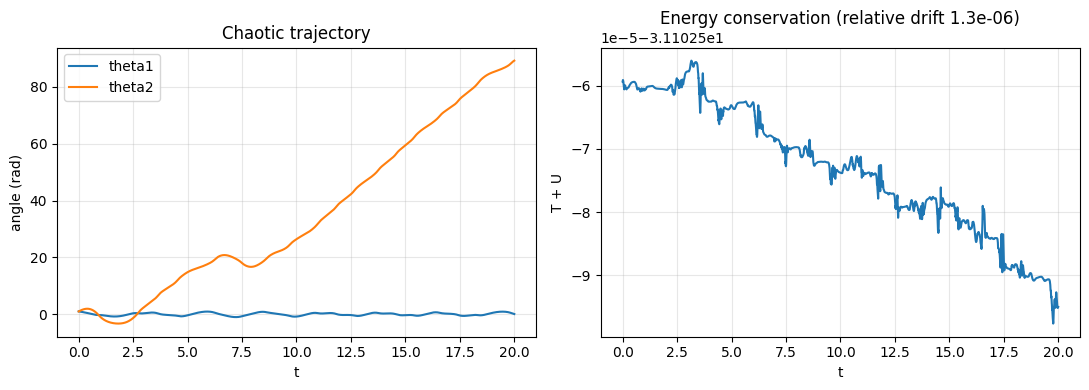

PASS: energy is conserved to within integration tolerance over the full chaotic run.


In [3]:
params = (9.81, 2.0, 1.0, 2.0, 1.0)
N = 4000
t_arr = np.linspace(0, 20, N)
sol = lg.integrate(dSdt, [1, -1, 1, 4], t_arr, params)
the1_t, w1_t, the2_t, w2_t = sol[:, 0], sol[:, 1], sol[:, 2], sol[:, 3]

E = np.array([energy(the1_t[i], the2_t[i], w1_t[i], w2_t[i], *params) for i in range(N)])
drift = E.max() - E.min()
print(f'Energy: mean={E.mean():.6f}, drift (max-min)={drift:.2e}, relative drift={drift/abs(E.mean()):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_arr, the1_t, label='theta1')
axes[0].plot(t_arr, the2_t, label='theta2')
axes[0].set_xlabel('t'); axes[0].set_ylabel('angle (rad)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Chaotic trajectory')

axes[1].plot(t_arr, E)
axes[1].set_xlabel('t'); axes[1].set_ylabel('T + U'); axes[1].grid(alpha=0.3)
axes[1].set_title(f'Energy conservation (relative drift {drift/abs(E.mean()):.1e})')
fig.tight_layout()
fig.savefig('media/double_pendulum_energy.png', dpi=150, bbox_inches='tight')
plt.show()

assert drift / abs(E.mean()) < 1e-3, f'energy drift too large: {drift/abs(E.mean()):.2e}'
print('PASS: energy is conserved to within integration tolerance over the full chaotic run.')

## Small-amplitude limit vs. `linearize()`

In [4]:
M, K, _ = lg.linearize(L, [the1, the2], t, equilibrium={the1: 0, the2: 0})
pvals = {g: 9.81, m1: 2.0, m2: 1.0, L1: 2.0, L2: 1.0}
freqs = lg.normal_mode_frequencies(M, K, pvals)
print('linearize() normal-mode frequencies:', freqs)

t_small = np.linspace(0, 100, 20000)
sol_small = lg.integrate(dSdt, [0.02, 0, -0.02, 0], t_small, params)
dt = t_small[1] - t_small[0]
spec = np.abs(np.fft.rfft(sol_small[:, 0] - sol_small[:, 0].mean()))
fr = 2 * np.pi * np.fft.rfftfreq(len(t_small), d=dt)

from scipy.signal import find_peaks
peaks, _ = find_peaks(spec)
top = sorted(peaks[np.argsort(spec[peaks])[::-1][:2]], key=lambda i: fr[i])
fft_freqs = np.array([fr[i] for i in top])
print('FFT peak frequencies from full nonlinear integration:', fft_freqs)

err = np.max(np.abs(np.sort(fft_freqs) - np.sort(freqs)) / freqs)
print(f'max relative error: {err:.3f}')
assert err < 0.05, f'small-amplitude FFT frequencies do not match linearize() closely enough: {err:.3f}'
print('PASS: small-amplitude oscillation frequencies match the Lagrangian-derived linearization.')

linearize() normal-mode frequencies: [1.99799401 4.25211947]


FFT peak frequencies from full nonlinear integration: [2.01051877 4.27235238]
max relative error: 0.006
PASS: small-amplitude oscillation frequencies match the Lagrangian-derived linearization.


## Animation (chaotic run)

In [5]:
x1_t = params[3] * np.sin(the1_t)
y1_t = -params[3] * np.cos(the1_t)
x2_t = x1_t + params[4] * np.sin(the2_t)
y2_t = y1_t - params[4] * np.cos(the2_t)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_facecolor('k')
ax.set(xlim=(-3.5, 3.5), ylim=(-3.5, 3.5))
ax.set_xticks([]); ax.set_yticks([])
trail, = ax.plot([], [], '-', color='cyan', alpha=0.4, linewidth=0.8)
line, = ax.plot([], [], 'o-', color='white', markersize=8)
trail_x, trail_y = [], []

def animate(i):
    line.set_data([0, x1_t[i], x2_t[i]], [0, y1_t[i], y2_t[i]])
    trail_x.append(x2_t[i]); trail_y.append(y2_t[i])
    trail.set_data(trail_x[-300:], trail_y[-300:])
    return line, trail

ani = animation.FuncAnimation(fig, animate, frames=N, interval=20, blit=True)
ani.save('media/double_pendulum.mp4', writer='ffmpeg', fps=50, dpi=130)
plt.close(fig)
print('saved media/double_pendulum.mp4')

saved media/double_pendulum.mp4
